In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json
import random
from pathlib import Path

os.makedirs('artifacts/figures', exist_ok=True)

# Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [12]:
#Используем датасет FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

#20% от train
val_size = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}')

Train: 48000, Val: 12000, Test: 10000


In [13]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[256,128,64], num_classes=10,
                 dropout_prob=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_prob > 0:
                layers.append(nn.Dropout(dropout_prob))
            prev_size = h
        layers.append(nn.Linear(prev_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.net(x)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return total_loss / total, correct / total

def run_experiment(name, model_params, optimizer_name='Adam', lr=1e-3,
                   weight_decay=0, momentum=0, epochs=20, early_stopping_patience=None):
    model = MLP(**model_params).to(device)
    criterion = nn.CrossEntropyLoss()

    #Оптимизация
    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    #Логи
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:2d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        if early_stopping_patience is not None:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict()
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= early_stopping_patience:
                    print(f'Early stopping at epoch {epoch}')
                    model.load_state_dict(best_model_state)
                    break
        else:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history, best_val_acc


In [14]:
#Эксперементы E1-E4
base_model_params = {
    'input_size': 784,
    'hidden_sizes': [256,128,64],
    'num_classes': 10,
    'dropout_prob': 0.0,
    'use_batchnorm': False
}

epochs_base = 20
results = []  # для сбора строк в CSV

#E1
print("=== E1: Base (no reg) ===")
model_e1, hist_e1, best_val_e1 = run_experiment(
    'E1', base_model_params, optimizer_name='Adam', lr=1e-3, epochs=epochs_base
)
results.append({
    'experiment_id': 'E1',
    'model_summary': 'hidden=[256,128,64], no dropout, no BN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(hist_e1['train_loss']),
    'best_val_accuracy': best_val_e1,
    'best_val_loss': min(hist_e1['val_loss'])
})

#E2
print("=== E2: Dropout ===")
params_e2 = base_model_params.copy()
params_e2['dropout_prob'] = 0.3
model_e2, hist_e2, best_val_e2 = run_experiment(
    'E2', params_e2, optimizer_name='Adam', lr=1e-3, epochs=epochs_base
)
results.append({
    'experiment_id': 'E2',
    'model_summary': 'hidden=[256,128,64], dropout=0.3, no BN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(hist_e2['train_loss']),
    'best_val_accuracy': best_val_e2,
    'best_val_loss': min(hist_e2['val_loss'])
})

#E3
print("=== E3: BatchNorm ===")
params_e3 = base_model_params.copy()
params_e3['use_batchnorm'] = True
model_e3, hist_e3, best_val_e3 = run_experiment(
    'E3', params_e3, optimizer_name='Adam', lr=1e-3, epochs=epochs_base
)
results.append({
    'experiment_id': 'E3',
    'model_summary': 'hidden=[256,128,64], BN, no dropout',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(hist_e3['train_loss']),
    'best_val_accuracy': best_val_e3,
    'best_val_loss': min(hist_e3['val_loss'])
})

#E4
if best_val_e2 > best_val_e3:
    best_params = params_e2
    best_summary = 'hidden=[256,128,64], dropout=0.3, no BN (лучший из E2/E3)'
else:
    best_params = params_e3
    best_summary = 'hidden=[256,128,64], BN, no dropout (лучший из E2/E3)'

print(f"=== E4: EarlyStopping with {best_summary} ===")
model_e4, hist_e4, best_val_e4 = run_experiment(
    'E4', best_params, optimizer_name='Adam', lr=1e-3,
    epochs=30, early_stopping_patience=4
)
results.append({
    'experiment_id': 'E4',
    'model_summary': best_summary,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(hist_e4['train_loss']),
    'best_val_accuracy': best_val_e4,
    'best_val_loss': min(hist_e4['val_loss'])
})

#Сохраняем лучшую модель
best_model = model_e4
torch.save(best_model.state_dict(), 'artifacts/best_model.pt')

=== E1: Base (no reg) ===
Epoch  1 | Train Loss: 0.6618 Acc: 0.7609 | Val Loss: 0.4673 Acc: 0.8378
Epoch  2 | Train Loss: 0.4261 Acc: 0.8471 | Val Loss: 0.3964 Acc: 0.8556
Epoch  3 | Train Loss: 0.3755 Acc: 0.8647 | Val Loss: 0.3673 Acc: 0.8668
Epoch  4 | Train Loss: 0.3436 Acc: 0.8742 | Val Loss: 0.3556 Acc: 0.8736
Epoch  5 | Train Loss: 0.3202 Acc: 0.8822 | Val Loss: 0.3330 Acc: 0.8748
Epoch  6 | Train Loss: 0.3030 Acc: 0.8887 | Val Loss: 0.3304 Acc: 0.8809
Epoch  7 | Train Loss: 0.2880 Acc: 0.8931 | Val Loss: 0.3144 Acc: 0.8848
Epoch  8 | Train Loss: 0.2760 Acc: 0.8982 | Val Loss: 0.3472 Acc: 0.8776
Epoch  9 | Train Loss: 0.2645 Acc: 0.9011 | Val Loss: 0.3163 Acc: 0.8855
Epoch 10 | Train Loss: 0.2533 Acc: 0.9054 | Val Loss: 0.3264 Acc: 0.8844
Epoch 11 | Train Loss: 0.2419 Acc: 0.9087 | Val Loss: 0.3456 Acc: 0.8812
Epoch 12 | Train Loss: 0.2356 Acc: 0.9118 | Val Loss: 0.3364 Acc: 0.8846
Epoch 13 | Train Loss: 0.2227 Acc: 0.9171 | Val Loss: 0.3307 Acc: 0.8870
Epoch 14 | Train Loss: 0.

In [15]:
print("O1 (Adam, lr=0.1)")
model_o1, hist_o1, _ = run_experiment(
    'O1', best_params, optimizer_name='Adam', lr=0.1, epochs=8
)
results.append({
    'experiment_id': 'O1',
    'model_summary': best_summary,
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(hist_o1['train_loss']),
    'best_val_accuracy': max(hist_o1['val_acc']),
    'best_val_loss': min(hist_o1['val_loss'])
})

print("O2 (Adam, lr=1e-5)")
model_o2, hist_o2, _ = run_experiment(
    'O2', best_params, optimizer_name='Adam', lr=1e-5, epochs=8
)
results.append({
    'experiment_id': 'O2',
    'model_summary': best_summary,
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(hist_o2['train_loss']),
    'best_val_accuracy': max(hist_o2['val_acc']),
    'best_val_loss': min(hist_o2['val_loss'])
})

print("O3: SGD + momentum + weight decay")
model_o3, hist_o3, best_val_o3 = run_experiment(
    'O3', best_params, optimizer_name='SGD', lr=0.01, momentum=0.9,
    weight_decay=1e-4, epochs=15
)
results.append({
    'experiment_id': 'O3',
    'model_summary': best_summary,
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': len(hist_o3['train_loss']),
    'best_val_accuracy': best_val_o3,
    'best_val_loss': min(hist_o3['val_loss'])
})

O1 (Adam, lr=0.1)
Epoch  1 | Train Loss: 0.5801 Acc: 0.7881 | Val Loss: 0.5686 Acc: 0.8102
Epoch  2 | Train Loss: 0.4284 Acc: 0.8458 | Val Loss: 0.4451 Acc: 0.8394
Epoch  3 | Train Loss: 0.3938 Acc: 0.8577 | Val Loss: 0.4907 Acc: 0.8387
Epoch  4 | Train Loss: 0.3665 Acc: 0.8674 | Val Loss: 0.3829 Acc: 0.8655
Epoch  5 | Train Loss: 0.3475 Acc: 0.8732 | Val Loss: 0.3519 Acc: 0.8783
Epoch  6 | Train Loss: 0.3342 Acc: 0.8786 | Val Loss: 0.3704 Acc: 0.8688
Epoch  7 | Train Loss: 0.3260 Acc: 0.8820 | Val Loss: 0.4138 Acc: 0.8643
Epoch  8 | Train Loss: 0.3073 Acc: 0.8870 | Val Loss: 0.3752 Acc: 0.8773
O2 (Adam, lr=1e-5)
Epoch  1 | Train Loss: 1.6903 Acc: 0.5466 | Val Loss: 1.3792 Acc: 0.7042
Epoch  2 | Train Loss: 1.2621 Acc: 0.7369 | Val Loss: 1.1649 Acc: 0.7594
Epoch  3 | Train Loss: 1.0979 Acc: 0.7736 | Val Loss: 1.0275 Acc: 0.7841
Epoch  4 | Train Loss: 0.9852 Acc: 0.7946 | Val Loss: 0.9396 Acc: 0.8023
Epoch  5 | Train Loss: 0.9001 Acc: 0.8088 | Val Loss: 0.8585 Acc: 0.8153
Epoch  6 | Tra

In [16]:
df = pd.DataFrame(results)
df['dataset'] = 'KMNIST'
df['seed'] = 42
cols = ['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr',
        'momentum', 'weight_decay', 'epochs_trained', 'best_val_accuracy', 'best_val_loss']
df = df[cols]
df.to_csv('artifacts/runs.csv', index=False)
print("CSV сохранён.")

CSV сохранён.


In [17]:
best_config = {
    'experiment_id': 'E4',
    'dataset': 'KMNIST',
    'seed': 42,
    'model_params': best_params,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'weight_decay': 0,
    'early_stopping_patience': 4,
    'best_val_accuracy': best_val_e4,
    'test_accuracy': None
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

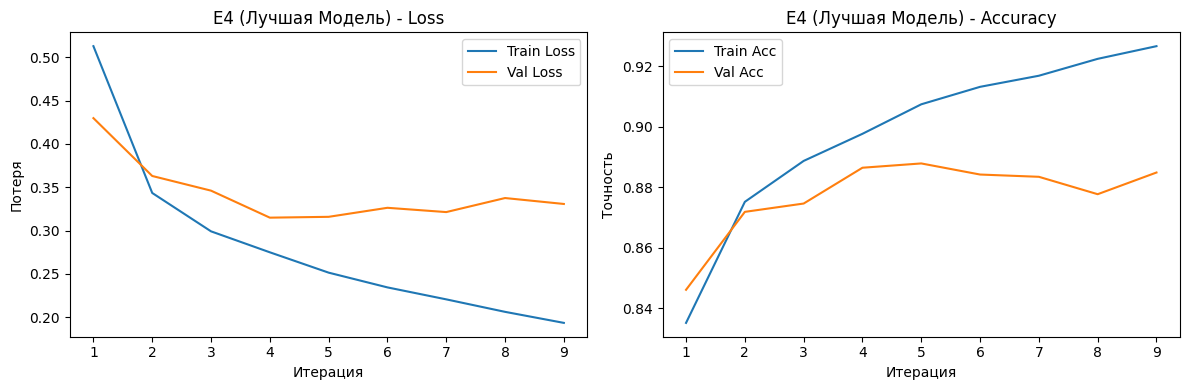

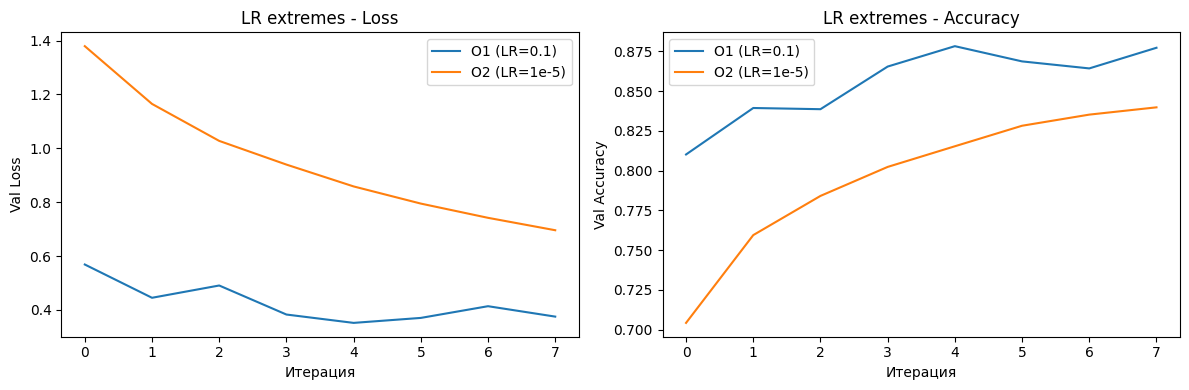

In [21]:
def plot_curves(history, title, save_path):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Итерация')
    plt.ylabel('Потеря')
    plt.legend()
    plt.title(f'{title} - Loss')

    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.xlabel('Итерация')
    plt.ylabel('Точность')
    plt.legend()
    plt.title(f'{title} - Accuracy')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

#E4
plot_curves(hist_e4, 'E4 (Лучшая Модель)', 'artifacts/figures/curves_best.png')

#O1 и O2
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist_o1['val_loss'], label='O1 (LR=0.1)')
plt.plot(hist_o2['val_loss'], label='O2 (LR=1e-5)')
plt.xlabel('Итерация')
plt.ylabel('Val Loss')
plt.legend()
plt.title('LR extremes - Loss')

plt.subplot(1,2,2)
plt.plot(hist_o1['val_acc'], label='O1 (LR=0.1)')
plt.plot(hist_o2['val_acc'], label='O2 (LR=1e-5)')
plt.xlabel('Итерация')
plt.ylabel('Val Accuracy')
plt.legend()
plt.title('LR extremes - Accuracy')
plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png')
plt.show()

In [23]:
best_model.load_state_dict(torch.load('artifacts/best_model.pt'))
test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss())
print(f'Test accuracy of best model: {test_acc:.4f}')
print(f'Test loss of best model: {test_loss:.4f}')

best_config['test_accuracy'] = test_acc
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

Test accuracy of best model: 0.8808
Test loss of best model: 0.3510
